In [2]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

Y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

In [3]:
class ScratchMLP:

    def __init__(
        self,
        input_size=2,
        hidden_size=2,
        output_size=1,
        learning_rate=3.0,
        seed=42
    ):

        self.learning_rate = learning_rate

        rng = np.random.default_rng(seed)

        # Input -> Hidden
        self.W1 = rng.normal(
            0,
            0.5,
            (input_size, hidden_size)
        )

        self.b1 = np.zeros((1, hidden_size))

        # Hidden -> Output
        self.W2 = rng.normal(
            0,
            0.5,
            (hidden_size, output_size)
        )

        self.b2 = np.zeros((1, output_size))


    # Sigmoid
    def sigmoid(self, z):

        z = np.clip(z, -500, 500)

        return 1 / (1 + np.exp(-z))


    # Forward propagation
    def forward(self, X):

        # Hidden layer
        self.Z1 = X @ self.W1 + self.b1

        self.A1 = self.sigmoid(self.Z1)

        # Output layer
        self.Z2 = self.A1 @ self.W2 + self.b2

        self.Y_hat = self.sigmoid(self.Z2)

        return self.Y_hat


    # MSE
    def calculate_loss(self, Y, Y_hat):

        return np.mean(
            (Y - Y_hat) ** 2
        )


    # Training
    def train(self, X, Y, epochs=10000):

        loss_history = []

        n = X.shape[0]

        for epoch in range(epochs):

            # Forward propagation
            Y_hat = self.forward(X)

            # Loss
            loss = self.calculate_loss(
                Y,
                Y_hat
            )

            loss_history.append(loss)

            # Output delta
            delta2 = (
                (Y_hat - Y)
                * Y_hat
                * (1 - Y_hat)
            )

            # Output gradients
            dW2 = (
                self.A1.T @ delta2
            ) / n

            db2 = (
                np.sum(
                    delta2,
                    axis=0,
                    keepdims=True
                ) / n
            )

            # Hidden delta
            delta1 = (
                delta2 @ self.W2.T
            ) * self.A1 * (1 - self.A1)

            # Hidden gradients
            dW1 = (
                X.T @ delta1
            ) / n

            db1 = (
                np.sum(
                    delta1,
                    axis=0,
                    keepdims=True
                ) / n
            )

            # Update parameters
            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2

            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

        return loss_history


    # Prediction
    def predict_probability(self, X):

        return self.forward(X)


    def predict(self, X):

        return (
            self.predict_probability(X) >= 0.5
        ).astype(int)

In [4]:
mlp = ScratchMLP(
    input_size=2,
    hidden_size=2,
    output_size=1,
    learning_rate=3.0,
    seed=42
)
loss_history = mlp.train(
    X,
    Y,
    epochs=10000
)
print("Final MSE:", loss_history[-1])
print("\nPredictions:")
probabilities = mlp.predict_probability(X)
predictions = mlp.predict(X)
for i in range(len(X)):
    print(
        X[i],
        "Actual:",
        int(Y[i][0]),
        "Probability:",
        round(float(probabilities[i][0]), 4),
        "Prediction:",
        int(predictions[i][0])
    )
print("\nW1:")
print(mlp.W1)
print("\nB1:")
print(mlp.b1)
print("\nW2:")
print(mlp.W2)
print("\nB2:")
print(mlp.b2)

Final MSE: 0.0003641898270243795

Predictions:
[0. 0.] Actual: 0 Probability: 0.0183 Prediction: 0
[0. 1.] Actual: 1 Probability: 0.9794 Prediction: 1
[1. 0.] Actual: 1 Probability: 0.9795 Prediction: 1
[1. 1.] Actual: 0 Probability: 0.0166 Prediction: 0

W1:
[[ 6.69604567 -7.01119198]
 [-6.45946836  7.15429841]]

B1:
[[3.25372693 3.56539941]]

W2:
[[-8.74750622]
 [-8.68203069]]

B2:
[[12.88192152]]


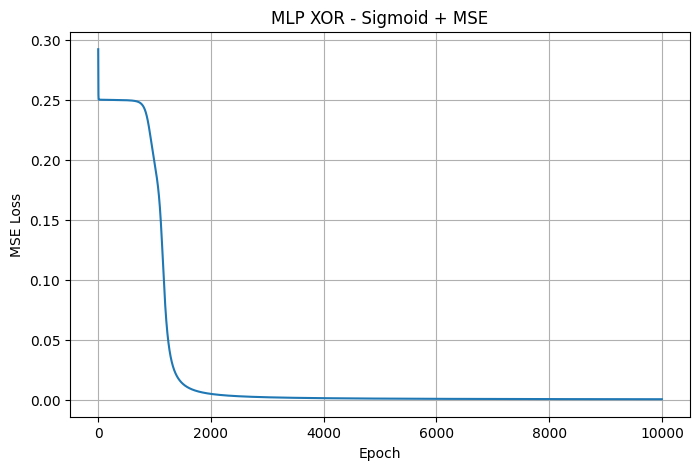

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP XOR - Sigmoid + MSE")

plt.grid(True)
plt.show()